In [1]:
import sys
import sympy as sp
from sympy import (pi, sin, cos, exp, Rational, symbols, Symbol, integrate, simplify,
                   DiracDelta, latex, init_printing)
import numpy as np
import matplotlib.pyplot as plt

# The paper's equations, transcribed once into SymPy and kept in sync with ms.tex
# by src/scripts/check_equations.py (src/derivations/equations.py)
sys.path.insert(0, '../src/derivations')
import equations as eqs

init_printing(use_latex='mathjax')

Accompanies Section `subsec:ft_cosine` (Fourier Transform: The Rotation Term $\mathcal{V}(t)$) of the paper; the general-inclination coefficients are derived in Appendix `app:fourier_visibility` (Fourier Coefficients of the Visibility Function).

# Fourier Transform of $\mathcal{V}(t) = \max\{\cos\beta(t),\, 0\}$

## Setup

The visibility function for a single spot on a rotating star is:

$$\mathcal{V}(t) = \max\{\cos\beta(t),\, 0\}$$

where (Eq. `eq:cos_beta`, Appendix `app:fourier_visibility`)

$$\cos\beta(t) = \underbrace{\cos I \sin\Phi}_{b_0} + \underbrace{\sin I \cos\Phi}_{b_1} \cos(\Lambda_0 + \omega_0 t),$$

with stellar inclination $I$ and spot latitude $\Phi \in [-\pi/2, \pi/2]$ (latitude measured from the stellar equator, not colatitude). As in the paper we set $\Lambda_0 = 0$ without loss of generality: a phase shift changes only the complex phase of $c_n$, not $|c_n|^2$.

For the **edge-on case** ($I = 90°$), this simplifies to:

$$\mathcal{V}(t) = \max\{\cos\Phi\,\cos(\omega_0 t),\, 0\} = \cos\Phi \cdot \max\{\cos(\omega_0 t),\, 0\},$$

where pulling $\cos\Phi$ out of the $\max$ uses $\cos\Phi \ge 0$ for $|\Phi| \le \pi/2$.

Since $\mathcal{V}(t)$ is periodic with period $P = 2\pi/\omega_0$, it has a discrete Fourier series (Eq. `eq:cap_fourier_series`):

$$\mathcal{V}(t) = \sum_{n=-\infty}^{\infty} c_n\, e^{in\omega_0 t}$$

We derive the coefficients $c_n$ analytically using SymPy, check them against the paper's Eqs. `eq:cn_edgeon` and `eq:cn_general` (taken from the equation registry, `src/derivations/equations.py`), and check the second-order Fourier transform $\hat{\mathcal{V}}(\omega)$ against Eq. `eq:cap_hat_explicit`.

## 1. Fourier coefficients of the half-rectified cosine

For $f(\theta) = \max\{\cos\theta,\, 0\}$, the complex Fourier coefficients are:

$$c_n = \frac{1}{2\pi}\int_{-\pi}^{\pi} f(\theta)\, e^{-in\theta}\, d\theta = \frac{1}{2\pi}\int_{-\pi/2}^{\pi/2} \cos\theta\, e^{-in\theta}\, d\theta$$

since $\cos\theta > 0$ only on $(-\pi/2,\, \pi/2)$. This is Eq. `eq:cn_integral` with $b_0 = 0$, $b_1 = 1$ and $\theta_{\rm vis} = \pi/2$.

In [2]:
theta = Symbol('theta', real=True)    # rotation phase omega_0 t + Lambda_0
n_sym = Symbol('n', integer=True)

# General Fourier coefficient: c_n = (1/2pi) int_{-pi/2}^{pi/2} cos(theta) exp(-i n theta) dtheta
c_n_integral = Rational(1, 2) / pi * integrate(cos(theta) * exp(-sp.I * n_sym * theta), (theta, -pi/2, pi/2))
c_n_general = simplify(c_n_integral)

print("General c_n =")
c_n_general

General c_n =


⎧          1/4             for n = -1 ∨ n = 1
⎪                                            
⎪                 -ⅈ⋅π⋅n                     
⎪                 ───────                    
⎨⎛    n + 1    ⎞     2                       
⎪⎝(-1)      - 1⎠⋅ℯ                           
⎪────────────────────────      otherwise     
⎪          ⎛ 2    ⎞                          
⎩      2⋅π⋅⎝n  - 1⎠                          

## 2. Evaluate $c_n$ for specific harmonics

Compute $c_0$, $c_{\pm 1}$, $c_{\pm 2}$, $c_{\pm 3}$, $c_{\pm 4}$ by direct integration.

In [3]:
# Evaluate c_n for n = -4, ..., 4 by substituting into the integral
coeffs = {}
for nval in range(-4, 5):
    cn = Rational(1, 2) / pi * integrate(cos(theta) * exp(-sp.I * nval * theta), (theta, -pi/2, pi/2))
    cn = simplify(cn)
    coeffs[nval] = cn
    print(f"c_{nval:+d} = {cn}  =  {float(complex(cn).real):.6f} + {float(complex(cn).imag):.6f}i")

c_-4 = -1/(15*pi)  =  -0.021221 + 0.000000i
c_-3 = 0  =  0.000000 + 0.000000i
c_-2 = 1/(3*pi)  =  0.106103 + 0.000000i
c_-1 = 1/4  =  0.250000 + 0.000000i
c_+0 = 1/pi  =  0.318310 + 0.000000i
c_+1 = 1/4  =  0.250000 + 0.000000i
c_+2 = 1/(3*pi)  =  0.106103 + 0.000000i


c_+3 = 0  =  0.000000 + 0.000000i
c_+4 = -1/(15*pi)  =  -0.021221 + 0.000000i


## 3. Verify: all $c_n$ are real and $c_{-n} = c_n$

Since $\max\{\cos\theta, 0\}$ is real and even, the Fourier coefficients must satisfy (as stated after Eq. `eq:cn_edgeon`):
- $c_n \in \mathbb{R}$ for all $n$
- $c_{-n} = c_n$

In [4]:
# Check symmetry and reality
print("Symmetry check: c_{-n} = c_n")
for nval in range(0, 5):
    assert coeffs[-nval] == coeffs[nval], f"FAILED: c_{-nval} != c_{nval}"
    assert sp.im(coeffs[nval]) == 0, f"FAILED: c_{nval} has imaginary part"
    print(f"  c_{-nval} = c_{nval} = {coeffs[nval]}  ✓")

print("\nAll coefficients are real and symmetric. ✓")

Symmetry check: c_{-n} = c_n
  c_0 = c_0 = 1/pi  ✓
  c_-1 = c_1 = 1/4  ✓
  c_-2 = c_2 = 1/(3*pi)  ✓
  c_-3 = c_3 = 0  ✓
  c_-4 = c_4 = -1/(15*pi)  ✓

All coefficients are real and symmetric. ✓


## 4. Closed-form expression for $c_n$ (Eq. `eq:cn_edgeon`)

For the half-rectified cosine, the coefficients follow a known pattern. Using $\cos\theta = \frac{1}{2}(e^{i\theta} + e^{-i\theta})$ (the steps of Eqs. `eq:cn_int_cos` and `eq:cn_result` with $\theta_{\rm vis} = \pi/2$):

$$c_n = \frac{1}{2\pi}\left[\frac{\sin\!\big(\frac{(1-n)\pi}{2}\big)}{1-n} + \frac{\sin\!\big(\frac{(1+n)\pi}{2}\big)}{1+n}\right] \quad (n \neq \pm 1), \qquad c_{\pm 1} = \frac{1}{4}$$

This gives the pattern of Eq. `eq:cn_edgeon` (where every coefficient carries the factor $\cos\Phi$):
- **$n = 0$**: $c_0 = 1/\pi$
- **$n = \pm 1$**: $c_{\pm 1} = 1/4$
- **Even $n = \pm 2, \pm 4, \ldots$**: $c_n = \frac{(-1)^{|n|/2+1}}{\pi(n^2 - 1)}$, so $c_{\pm 2} = +\frac{1}{3\pi}$ and $c_{\pm 4} = -\frac{1}{15\pi}$
- **Odd $n = \pm 3, \pm 5, \ldots$**: $c_n = 0$

The edge-on coefficients of $\mathcal{V}(t)$ are therefore $c_n = g_n\cos\Phi$, with $g_n$ the coefficients above ($g_0 = 1/\pi$, $g_1 = 1/4$, $g_2 = 1/(3\pi)$; Section `subsec:kernel_anal_case`).

In [5]:
# Verify the closed-form pattern against the directly integrated coefficients
print("Verify closed-form pattern:")
print(f"  c_0  = 1/pi = {1/np.pi:.6f}  (computed: {float(coeffs[0]):.6f})")
print(f"  c_±1 = 1/4  = {1/4:.6f}  (computed: {float(coeffs[1]):.6f})")

# Even harmonics: c_n = (-1)^(|n|/2+1) / (pi * (n^2 - 1)), so c_±2 = +1/(3*pi) and c_±4 = -1/(15*pi)
for nval in [-4, -2, 2, 4]:
    formula_val = (-1)**(abs(nval)//2 + 1) / (np.pi * (nval**2 - 1))
    computed_val = float(coeffs[nval])
    assert np.isclose(formula_val, computed_val), f"c_{nval} does not follow the even-n pattern"
    print(f"  c_{nval:+d}: formula = {formula_val:+.6f}, computed = {computed_val:+.6f}  ✓")

# Odd harmonics (n != ±1) vanish
for nval in [-3, 3]:
    assert coeffs[nval] == 0
    print(f"  c_{nval:+d}: computed = {float(coeffs[nval]):.6f}  (odd |n| >= 3 vanish)  ✓")

# The paper's Eq. eq:cn_edgeon (from the registry) includes the factor cos(Phi): c_n = g_n cos(Phi)
Phi = eqs.phi                                    # spot latitude, real, in [-pi/2, pi/2]
cn_edgeon_paper = eqs.get("eq:cn_edgeon").expr   # Piecewise in eqs.n
print("\nEq. eq:cn_edgeon vs cos(Phi) * direct integral:")
for nval in range(-4, 5):
    paper = cn_edgeon_paper.subs(eqs.n, nval)
    assert simplify(paper - cos(Phi) * coeffs[nval]) == 0, f"c_{nval} != Eq. eq:cn_edgeon"
    print(f"  c_{nval:+d} = {paper}  ✓")

print("\nSummary of non-zero coefficients g_n = c_n / cos(Phi):")
print(f"  g_0  = 1/π ≈ {1/np.pi:.6f}")
print(f"  g_±1 = 1/4 = 0.250000")
print(f"  g_±2 = +1/(3π) ≈ {1/(3*np.pi):.6f}")
print(f"  g_±4 = -1/(15π) ≈ {-1/(15*np.pi):.6f}")

Verify closed-form pattern:
  c_0  = 1/pi = 0.318310  (computed: 0.318310)
  c_±1 = 1/4  = 0.250000  (computed: 0.250000)
  c_-4: formula = -0.021221, computed = -0.021221  ✓
  c_-2: formula = +0.106103, computed = +0.106103  ✓
  c_+2: formula = +0.106103, computed = +0.106103  ✓
  c_+4: formula = -0.021221, computed = -0.021221  ✓
  c_-3: computed = 0.000000  (odd |n| >= 3 vanish)  ✓
  c_+3: computed = 0.000000  (odd |n| >= 3 vanish)  ✓

Eq. eq:cn_edgeon vs cos(Phi) * direct integral:
  c_-4 = -cos(Phi)/(15*pi)  ✓
  c_-3 = 0  ✓
  c_-2 = cos(Phi)/(3*pi)  ✓
  c_-1 = cos(Phi)/4  ✓
  c_+0 = cos(Phi)/pi  ✓
  c_+1 = cos(Phi)/4  ✓
  c_+2 = cos(Phi)/(3*pi)  ✓
  c_+3 = 0  ✓
  c_+4 = -cos(Phi)/(15*pi)  ✓

Summary of non-zero coefficients g_n = c_n / cos(Phi):
  g_0  = 1/π ≈ 0.318310
  g_±1 = 1/4 = 0.250000
  g_±2 = +1/(3π) ≈ 0.106103
  g_±4 = -1/(15π) ≈ -0.021221


## 5. Fourier transform of $\mathcal{V}(t) = \cos\Phi \cdot \max\{\cos(\omega_0 t), 0\}$

Since $\mathcal{V}(t)$ is periodic, its Fourier transform is a train of Dirac deltas (Eq. `eq:cap_hat`):

$$\hat{\mathcal{V}}(\omega) = 2\pi \sum_n c_n\, \delta(\omega - n\omega_0)$$

with the edge-on coefficients $c_n = g_n\cos\Phi$ of Eq. `eq:cn_edgeon`. We build it from the directly integrated coefficients above, truncated to second harmonic order ($|n| \le 2$).

Note that $\omega$ must be declared real but not positive in SymPy: with `positive=True`, `DiracDelta(omega)` and `DiracDelta(omega + omega_0)` evaluate to zero and the DC and negative-frequency terms silently drop out.

In [6]:
omega = Symbol('omega', real=True)   # real, NOT positive, so that delta(omega) and delta(omega + n omega_0) survive
omega0 = eqs.omega0                  # rotation frequency (positive)

# V_hat(omega) = 2*pi * sum_{|n| <= 2} c_n delta(omega - n omega_0), with c_n = cos(Phi) * coeffs[n]  (Eq. eq:cap_hat)
V_hat = sp.expand(2 * pi * sum(cos(Phi) * coeffs[nval] * DiracDelta(omega - nval * omega0)
                               for nval in range(-2, 3)))

print("V_hat(omega) to second order =")
V_hat

V_hat(omega) to second order =


                2⋅cos(Φ)⋅δ(ω - 2⋅ω₀)   π⋅cos(Φ)⋅δ(ω - ω₀)   π⋅cos(Φ)⋅δ(ω + ω₀) ↪
2⋅cos(Φ)⋅δ(ω) + ──────────────────── + ────────────────── + ────────────────── ↪
                         3                     2                    2          ↪

↪    2⋅cos(Φ)⋅δ(ω + 2⋅ω₀)
↪  + ────────────────────
↪             3          

### Check against the paper: Eq. `eq:cap_hat_explicit`

The paper writes the second-order transform as

$$\hat{\mathcal{V}}(\omega) \approx 2\pi\left[c_0\,\delta(\omega) + c_1\big[\delta(\omega - \omega_0) + \delta(\omega + \omega_0)\big] + c_2\big[\delta(\omega - 2\omega_0) + \delta(\omega + 2\omega_0)\big]\right].$$

Substituting the edge-on coefficients of Eq. `eq:cn_edgeon` ($c_0 = \cos\Phi/\pi$, $c_1 = \cos\Phi/4$, $c_2 = +\cos\Phi/(3\pi)$) must reproduce $\hat{\mathcal{V}}(\omega)$ above exactly. Term by term this means: every $c_n$ is real, the $\pm n\omega_0$ deltas enter with a plus sign and equal weight (an even function), the overall prefactor is $2\pi$, and the DC term is $2\cos\Phi\,\delta(\omega)$.

In [7]:
# Eq. eq:cap_hat_explicit as typeset, with symbolic c_0, c_1, c_2
c0_, c1_, c2_ = symbols('c_0 c_1 c_2')
V_hat_paper = 2 * pi * (
    c0_ * DiracDelta(omega)
    + c1_ * (DiracDelta(omega - omega0) + DiracDelta(omega + omega0))
    + c2_ * (DiracDelta(omega - 2 * omega0) + DiracDelta(omega + 2 * omega0)))

# Substitute the edge-on coefficients of Eq. eq:cn_edgeon (registry)
V_hat_paper_edgeon = sp.expand(V_hat_paper.subs({c0_: cn_edgeon_paper.subs(eqs.n, 0),
                                                 c1_: cn_edgeon_paper.subs(eqs.n, 1),
                                                 c2_: cn_edgeon_paper.subs(eqs.n, 2)}))

assert sp.expand(V_hat - V_hat_paper_edgeon) == 0, "V_hat != Eq. eq:cap_hat_explicit with Eq. eq:cn_edgeon"
print("V_hat(omega) = Eq. eq:cap_hat_explicit with the c_n of Eq. eq:cn_edgeon substituted  ✓")

# Coefficient of each delta is 2*pi*c_n: real, positive here, and the same for +n and -n
expected = {0: 2 * cos(Phi), 1: pi * cos(Phi) / 2, 2: 2 * cos(Phi) / 3}
print("\nCoefficient of delta(omega - n*omega_0) = 2*pi*c_n:")
for nval in range(-2, 3):
    coef = V_hat.coeff(DiracDelta(omega - nval * omega0))
    assert simplify(coef - expected[abs(nval)]) == 0 and sp.im(coef) == 0
    print(f"  n = {nval:+d}:  {coef}")

V_hat(omega) = Eq. eq:cap_hat_explicit with the c_n of Eq. eq:cn_edgeon substituted  ✓

Coefficient of delta(omega - n*omega_0) = 2*pi*c_n:
  n = -2:  2*cos(Phi)/3
  n = -1:  pi*cos(Phi)/2
  n = +0:  2*cos(Phi)
  n = +1:  pi*cos(Phi)/2
  n = +2:  2*cos(Phi)/3


## 6. Numerical verification

Reconstruct $\mathcal{V}(t)$ from the Fourier series (Eq. `eq:cap_fourier_series`) and compare with the exact $\max\{\cos\Phi\cos(\omega_0 t), 0\}$.

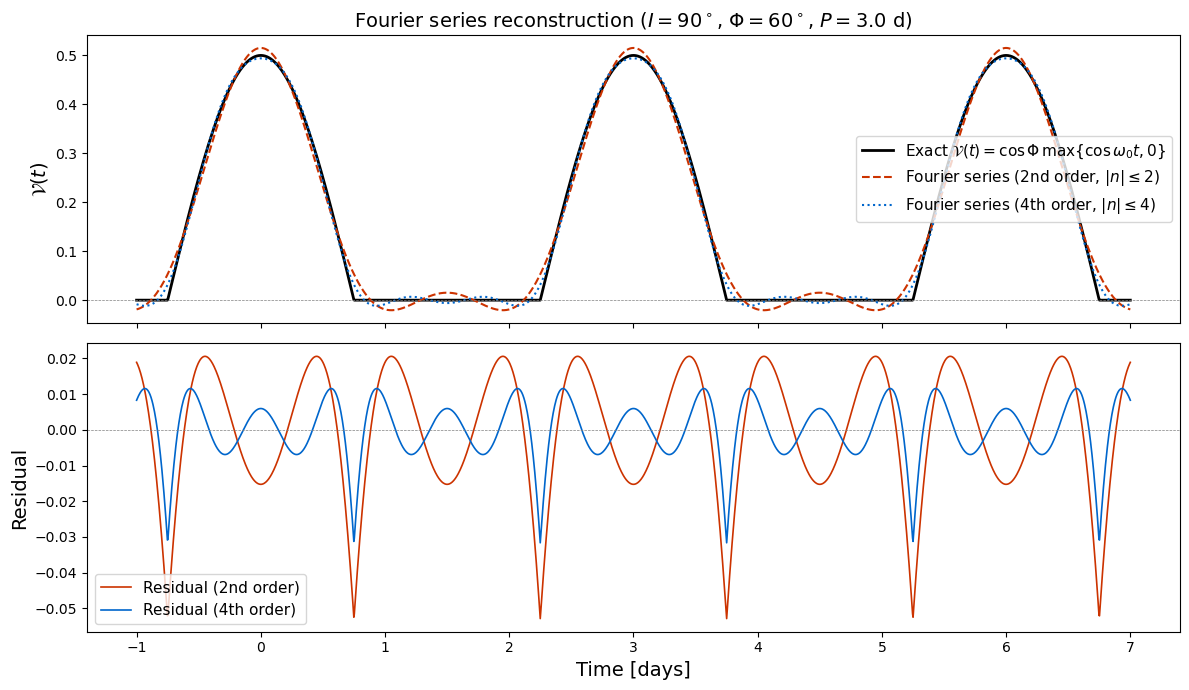

In [8]:
# Numerical verification
P = 3.0
w0 = 2 * np.pi / P
phi_deg = 60
phi = np.radians(phi_deg)
cos_phi = np.cos(phi)

t = np.linspace(-1, 7, 2000)

# Exact signal
V_exact = cos_phi * np.maximum(np.cos(w0 * t), 0)

# Fourier reconstruction to N-th harmonic
def fourier_reconstruct(t, w0, cos_phi, N_max):
    """Reconstruct V(t) from the edge-on Fourier coefficients c_n = g_n cos(Phi) (Eq. eq:cn_edgeon)."""
    result = np.zeros_like(t, dtype=complex)
    for nval in range(-N_max, N_max + 1):
        if abs(nval) <= 4:
            gn = float(coeffs[nval])                     # exact, from SymPy
        elif nval % 2 == 0:
            gn = (-1)**(abs(nval)//2 + 1) / (np.pi * (nval**2 - 1))
        else:
            gn = 0.0                                     # odd |n| >= 3
        result += gn * np.exp(1j * nval * w0 * t)
    return cos_phi * np.real(result)

# Reconstructions at different truncation orders
V_2nd = fourier_reconstruct(t, w0, cos_phi, 2)
V_4th = fourier_reconstruct(t, w0, cos_phi, 4)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top: waveforms
ax1.plot(t, V_exact, 'k-', lw=2, label=r'Exact $\mathcal{V}(t) = \cos\Phi\,\max\{\cos\omega_0 t, 0\}$')
ax1.plot(t, V_2nd, '--', color='#CC3300', lw=1.5, label=r'Fourier series (2nd order, $|n| \leq 2$)')
ax1.plot(t, V_4th, ':', color='#0066CC', lw=1.5, label=r'Fourier series (4th order, $|n| \leq 4$)')
ax1.set_ylabel(r'$\mathcal{V}(t)$', fontsize=14)
ax1.legend(fontsize=11)
ax1.set_title(rf'Fourier series reconstruction ($I = 90^\circ$, $\Phi = {phi_deg}^\circ$, $P = {P}$ d)', fontsize=14)
ax1.axhline(0, color='gray', lw=0.5, ls='--')

# Bottom: residuals
ax2.plot(t, V_exact - V_2nd, '-', color='#CC3300', lw=1.2, label='Residual (2nd order)')
ax2.plot(t, V_exact - V_4th, '-', color='#0066CC', lw=1.2, label='Residual (4th order)')
ax2.set_xlabel('Time [days]', fontsize=14)
ax2.set_ylabel('Residual', fontsize=14)
ax2.legend(fontsize=11)
ax2.axhline(0, color='gray', lw=0.5, ls='--')

plt.tight_layout()
plt.show()

## 7. Squared Fourier coefficients $|c_n|^2$

These enter the single-spot kernel via the Wiener–Khinchin theorem (Eq. `eq:kernel_single_spot`):

$$\mathcal{K}(\tau) = \alpha_{\max}^4\, R_\Gamma(\tau)\left[|c_0|^2 + 2\sum_{n\ge1}|c_n|^2\cos(n\omega_0\tau)\right].$$

Since all $c_n$ are real, $|c_n|^2 = c_n^2 = g_n^2\cos^2\Phi$ for edge-on viewing. Below we list $g_n^2$ (that is, $|c_n|^2$ per unit $\cos^2\Phi$), the fraction of the power $\sum_n |c_n|^2$ carried by each harmonic (independent of $\Phi$), and the latitude average for a uniform $p(\Phi) = 1/\pi$ on $[-\pi/2, \pi/2]$, $\langle|c_n|^2\rangle_\Phi = g_n^2/2$ (Section `subsec:kernel_anal_case`).

In [9]:
# |c_n|^2 = g_n^2 cos^2(Phi) for edge-on viewing, with g_n = coeffs[n]
print("Squared Fourier coefficients g_n^2 = |c_n|^2 / cos^2(Phi):")
print("="*50)
for nval in range(0, 5):
    cn_val = coeffs[nval]
    cn_sq = simplify(cn_val**2)
    cn_sq_numeric = float(cn_sq)
    if cn_sq_numeric > 0:
        print(f"  g_{nval}^2 = ({cn_val})^2 = {cn_sq}  ≈ {cn_sq_numeric:.8f}")

print()
print("Power fractions (relative to the power in n = 0, ±1, ±2, ±4):")
total_power = float(coeffs[0]**2 + 2*coeffs[1]**2 + 2*coeffs[2]**2 + 2*coeffs[4]**2)
for nval, label in [(0, "DC"), (1, "1st harmonic"), (2, "2nd harmonic"), (4, "4th harmonic")]:
    cn_sq = float(coeffs[nval]**2)
    mult = 1 if nval == 0 else 2
    frac = mult * cn_sq / total_power * 100
    print(f"  n={nval} ({label}): {frac:.1f}%")

# Parseval: sum_n |g_n|^2 = (1/2pi) int max(cos theta, 0)^2 dtheta = 1/4
parseval = integrate(cos(theta)**2, (theta, -pi/2, pi/2)) / (2 * pi)
print(f"\nPower in n = 0, ±1, ±2, ±4: {total_power:.8f}")
print(f"Exact total power (Parseval): {parseval} = {float(parseval):.8f}")

# Latitude average for p(Phi) = 1/pi on [-pi/2, pi/2] (Phi is latitude, not colatitude)
print("\nLatitude average <|c_n|^2>_Phi = (1/pi) int_{-pi/2}^{pi/2} |c_n(Phi)|^2 dPhi:")
for nval in range(0, 3):
    avg = simplify(integrate(cn_edgeon_paper.subs(eqs.n, nval)**2 / pi, (Phi, -pi/2, pi/2)))
    assert simplify(avg - coeffs[nval]**2 / 2) == 0
    print(f"  <|c_{nval}|^2>_Phi = {avg} = g_{nval}^2 / 2  ✓")

Squared Fourier coefficients g_n^2 = |c_n|^2 / cos^2(Phi):
  g_0^2 = (1/pi)^2 = pi**(-2)  ≈ 0.10132118
  g_1^2 = (1/4)^2 = 1/16  ≈ 0.06250000
  g_2^2 = (1/(3*pi))^2 = 1/(9*pi**2)  ≈ 0.01125791
  g_4^2 = (-1/(15*pi))^2 = 1/(225*pi**2)  ≈ 0.00045032

Power fractions (relative to the power in n = 0, ±1, ±2, ±4):
  n=0 (DC): 40.6%
  n=1 (1st harmonic): 50.1%
  n=2 (2nd harmonic): 9.0%
  n=4 (4th harmonic): 0.4%

Power in n = 0, ±1, ±2, ±4: 0.24973763
Exact total power (Parseval): 1/4 = 0.25000000

Latitude average <|c_n|^2>_Phi = (1/pi) int_{-pi/2}^{pi/2} |c_n(Phi)|^2 dPhi:
  <|c_0|^2>_Phi = 1/(2*pi**2) = g_0^2 / 2  ✓
  <|c_1|^2>_Phi = 1/32 = g_1^2 / 2  ✓
  <|c_2|^2>_Phi = 1/(18*pi**2) = g_2^2 / 2  ✓


## 8. General case: $I \neq 90°$ (Eq. `eq:cn_general`, Appendix `app:fourier_visibility`)

For general inclination, $\cos\beta(t) = b_0 + b_1\cos(\omega_0 t)$ where $b_0 = \cos I\sin\Phi$ and $b_1 = \sin I\cos\Phi$. For $b_1 > 0$ and $|b_0| < b_1$ the spot is visible when (Eq. `eq:theta_vis`)

$$\cos\beta(t) > 0 \iff |\omega_0 t| < \theta_{\rm vis} = \arccos(-b_0/b_1),$$

that is, for a fraction $\Delta = \theta_{\rm vis}/\pi$ of each rotation (the duty cycle). If $b_0 - b_1 \ge 0$ the spot is always visible ($\theta_{\rm vis} = \pi$); if $b_0 + b_1 \le 0$ it is never visible ($\theta_{\rm vis} = 0$, $c_n \equiv 0$).

The Fourier coefficients become (Eq. `eq:cn_integral`)

$$c_n = \frac{1}{2\pi}\int_{-\theta_{\rm vis}}^{\theta_{\rm vis}} (b_0 + b_1\cos\theta)\, e^{-in\theta}\, d\theta,$$

whose closed form is the boxed Eq. `eq:cn_general`,

$$c_n = \frac{1}{\pi}\left[\frac{b_0\sin(n\,\theta_{\rm vis})}{n} + \frac{b_1}{2}\left(\frac{\sin\big((n-1)\theta_{\rm vis}\big)}{n-1} + \frac{\sin\big((n+1)\theta_{\rm vis}\big)}{n+1}\right)\right],$$

with $c_0 = (b_0\,\theta_{\rm vis} + b_1\sin\theta_{\rm vis})/\pi$ and $c_{\pm 1} = (b_0\sin\theta_{\rm vis} + b_1[\theta_{\rm vis} + \sin\theta_{\rm vis}\cos\theta_{\rm vis}]/2)/\pi$ as its removable-singularity limits.

In [10]:
# General case: c_n for arbitrary inclination, with the registry's symbols:
# b_0 real (Phi can be negative), b_1 > 0, theta_v = theta_vis > 0, n integer
b0_sym, b1_sym, theta_vis, n_sym2 = eqs.b0, eqs.b1, eqs.theta_vis, eqs.n

# The integrand: (b0 + b1*cos(theta)) * exp(-i*n*theta)
integrand = (b0_sym + b1_sym * cos(theta)) * exp(-sp.I * n_sym2 * theta)

# Compute the integral symbolically
cn_general = Rational(1, 2) / pi * integrate(integrand, (theta, -theta_vis, theta_vis))
cn_general_simplified = simplify(cn_general)

print("General c_n (symbolic n; SymPy splits off n = 0 and n = ±1):")
cn_general_simplified

General c_n (symbolic n; SymPy splits off n = 0 and n = ±1):


⎧⎛                                                                             ↪
⎪⎝2⋅ⅈ⋅b₀ + ⅈ⋅b₁⋅θᵥ⋅sin(θᵥ) + b₁⋅θᵥ⋅cos(θᵥ) + b₁⋅sin(θᵥ) + (-2⋅ⅈ⋅b₀ - ⅈ⋅b₁⋅θᵥ⋅s ↪
⎪───────────────────────────────────────────────────────────────────────────── ↪
⎪                                                               4⋅π            ↪
⎪                                                                              ↪
⎪                                                       b₀⋅θᵥ + b₁⋅sin(θᵥ)     ↪
⎪                                                       ──────────────────     ↪
⎨                                                               π              ↪
⎪                                                                              ↪
⎪   ⎛      2                2                          ⎛        2              ↪
⎪   ⎝ⅈ⋅b₀⋅n  - ⅈ⋅b₀ + ⅈ⋅b₁⋅n ⋅cos(θᵥ) - b₁⋅n⋅sin(θᵥ) + ⎝- ⅈ⋅b₀⋅n  + ⅈ⋅b₀ - ⅈ⋅b ↪
⎪   ────────────────────────────────────────────────────────────────────────── ↪
⎪                           

In [11]:
def is_zero(expr):
    """Rewrite trig functions as complex exponentials before simplifying."""
    return simplify(sp.expand(expr.rewrite(exp))) == 0

cn_general_paper = eqs.get("eq:cn_general").expr   # closed form, n != 0, ±1 (registry)
# c_0 and c_{±1}, printed in the text after Eq. eq:cn_general
c0_paper = (b0_sym * theta_vis + b1_sym * sin(theta_vis)) / pi
c1_paper = (b0_sym * sin(theta_vis) + b1_sym * (theta_vis + sin(theta_vis) * cos(theta_vis)) / 2) / pi

# Generic-n branch of the symbolic result vs Eq. eq:cn_general
(generic,) = [e for e, cond in cn_general_simplified.args if cond == True]
assert is_zero(generic - cn_general_paper), "symbolic c_n != Eq. eq:cn_general"
print("Generic-n branch of the integral = Eq. eq:cn_general  ✓")

# Specific harmonics: direct integral vs the paper's closed form (and c_0, c_±1)
print("\nGeneral c_n for specific harmonics (direct integral = paper):")
print("="*60)
cn_direct = {}
for nval in range(-4, 5):
    cn_val = simplify(Rational(1, 2) / pi * integrate(
        (b0_sym + b1_sym * cos(theta)) * exp(-sp.I * nval * theta),
        (theta, -theta_vis, theta_vis)))
    cn_direct[nval] = cn_val
    paper = c0_paper if nval == 0 else c1_paper if abs(nval) == 1 else cn_general_paper.subs(n_sym2, nval)
    assert is_zero(cn_val - paper), f"c_{nval} != paper"
    print(f"  c_{nval:+d} = {paper}  ✓")

# c_{-n} = c_n also for general inclination (V is real and even once Lambda_0 = 0)
for nval in range(1, 5):
    assert is_zero(cn_direct[-nval] - cn_direct[nval])
print("\nc_{-n} = c_n for n = 1..4  ✓")

# c_0 and c_±1 are removable singularities of Eq. eq:cn_general (n treated as continuous)
n_c = Symbol('n_c', real=True)
cn_cont = cn_general_paper.subs(n_sym2, n_c)
assert simplify(sp.limit(cn_cont, n_c, 0) - c0_paper) == 0
assert simplify(sp.limit(cn_cont, n_c, 1) - c1_paper) == 0
assert simplify(sp.limit(cn_cont, n_c, -1) - c1_paper) == 0
print("Limits n -> 0 and n -> ±1 of Eq. eq:cn_general give c_0 and c_±1  ✓")

Generic-n branch of the integral = Eq. eq:cn_general  ✓

General c_n for specific harmonics (direct integral = paper):


  c_-4 = (b_0*sin(4*theta_v)/4 + b_1*(sin(3*theta_v)/3 + sin(5*theta_v)/5)/2)/pi  ✓
  c_-3 = (b_0*sin(3*theta_v)/3 + b_1*(sin(2*theta_v)/2 + sin(4*theta_v)/4)/2)/pi  ✓


  c_-2 = (b_0*sin(2*theta_v)/2 + b_1*(sin(theta_v) + sin(3*theta_v)/3)/2)/pi  ✓
  c_-1 = (b_0*sin(theta_v) + b_1*(theta_v + sin(theta_v)*cos(theta_v))/2)/pi  ✓
  c_+0 = (b_0*theta_v + b_1*sin(theta_v))/pi  ✓


  c_+1 = (b_0*sin(theta_v) + b_1*(theta_v + sin(theta_v)*cos(theta_v))/2)/pi  ✓
  c_+2 = (b_0*sin(2*theta_v)/2 + b_1*(sin(theta_v) + sin(3*theta_v)/3)/2)/pi  ✓


  c_+3 = (b_0*sin(3*theta_v)/3 + b_1*(sin(2*theta_v)/2 + sin(4*theta_v)/4)/2)/pi  ✓
  c_+4 = (b_0*sin(4*theta_v)/4 + b_1*(sin(3*theta_v)/3 + sin(5*theta_v)/5)/2)/pi  ✓

c_{-n} = c_n for n = 1..4  ✓


Limits n -> 0 and n -> ±1 of Eq. eq:cn_general give c_0 and c_±1  ✓


In [12]:
# Verify: substitute I = 90 deg (b_0 = 0, b_1 = cos(Phi), theta_vis = pi/2) to recover Eq. eq:cn_edgeon
print("Verification: I=90° (b_0=0, b_1=cos(Phi), theta_vis=pi/2)")
print("="*60)

for nval in range(0, 5):
    cn_edgeon = simplify(cn_direct[nval].subs([(b0_sym, 0), (b1_sym, cos(Phi)), (theta_vis, pi/2)]))
    cn_expected = cn_edgeon_paper.subs(eqs.n, nval)   # Eq. eq:cn_edgeon
    match = simplify(cn_edgeon - cn_expected) == 0
    assert match
    print(f"  c_{nval} = {cn_edgeon}  (Eq. eq:cn_edgeon: {cn_expected})  match: {match}")

Verification: I=90° (b_0=0, b_1=cos(Phi), theta_vis=pi/2)
  c_0 = cos(Phi)/pi  (Eq. eq:cn_edgeon: cos(Phi)/pi)  match: True
  c_1 = cos(Phi)/4  (Eq. eq:cn_edgeon: cos(Phi)/4)  match: True
  c_2 = cos(Phi)/(3*pi)  (Eq. eq:cn_edgeon: cos(Phi)/(3*pi))  match: True
  c_3 = 0  (Eq. eq:cn_edgeon: 0)  match: True
  c_4 = -cos(Phi)/(15*pi)  (Eq. eq:cn_edgeon: -cos(Phi)/(15*pi))  match: True


## 9. Numerical comparison across inclinations

Evaluate $|c_n|^2$ from the closed form of Eq. `eq:cn_general` (with the $c_0$, $c_{\pm 1}$ limits) for several $(I, \Phi)$, and compare with (i) an FFT of one rotation of $\mathcal{V}(t)$ and (ii) the `spotgp` implementation, `spotgp.visibility._cn_general_jax`. The window half-width is $\theta_{\rm vis} = \arccos(-b_0/b_1)$ with the argument clipped to $[-1, 1]$, which gives $\theta_{\rm vis} = \pi$ for an always-visible spot ($b_0 \ge b_1$) and $0$ for a never-visible one. The case $I = \Phi = 60°$ has $b_0 = b_1$ exactly, on the boundary of the always-visible region ($\theta_{\rm vis} = \pi$); $I = 30°$, $\Phi = 60°$ is circumpolar ($\Phi \ge I$); $\Phi = -30°$ is a southern-hemisphere spot ($b_0 < 0$, $\Delta < 1/2$).

I = 90°, Phi = +30°: Delta = theta_vis/pi = 0.500;  max abs diff in |c_n|^2: vs FFT 7.5e-09, vs spotgp 1.4e-17
I = 90°, Phi = +60°: Delta = theta_vis/pi = 0.500;  max abs diff in |c_n|^2: vs FFT 2.5e-09, vs spotgp 6.9e-18
I = 70°, Phi = +45°: Delta = theta_vis/pi = 0.619;  max abs diff in |c_n|^2: vs FFT 1.7e-09, vs spotgp 4.2e-17
I = 60°, Phi = +60°: Delta = theta_vis/pi = 1.000;  max abs diff in |c_n|^2: vs FFT 2.8e-17, vs spotgp 2.7e-66
I = 30°, Phi = +60°: Delta = theta_vis/pi = 1.000;  max abs diff in |c_n|^2: vs FFT 6.9e-18, vs spotgp 0.0e+00
I = 70°, Phi = -30°: Delta = theta_vis/pi = 0.433;  max abs diff in |c_n|^2: vs FFT 3.5e-09, vs spotgp 8.1e-20


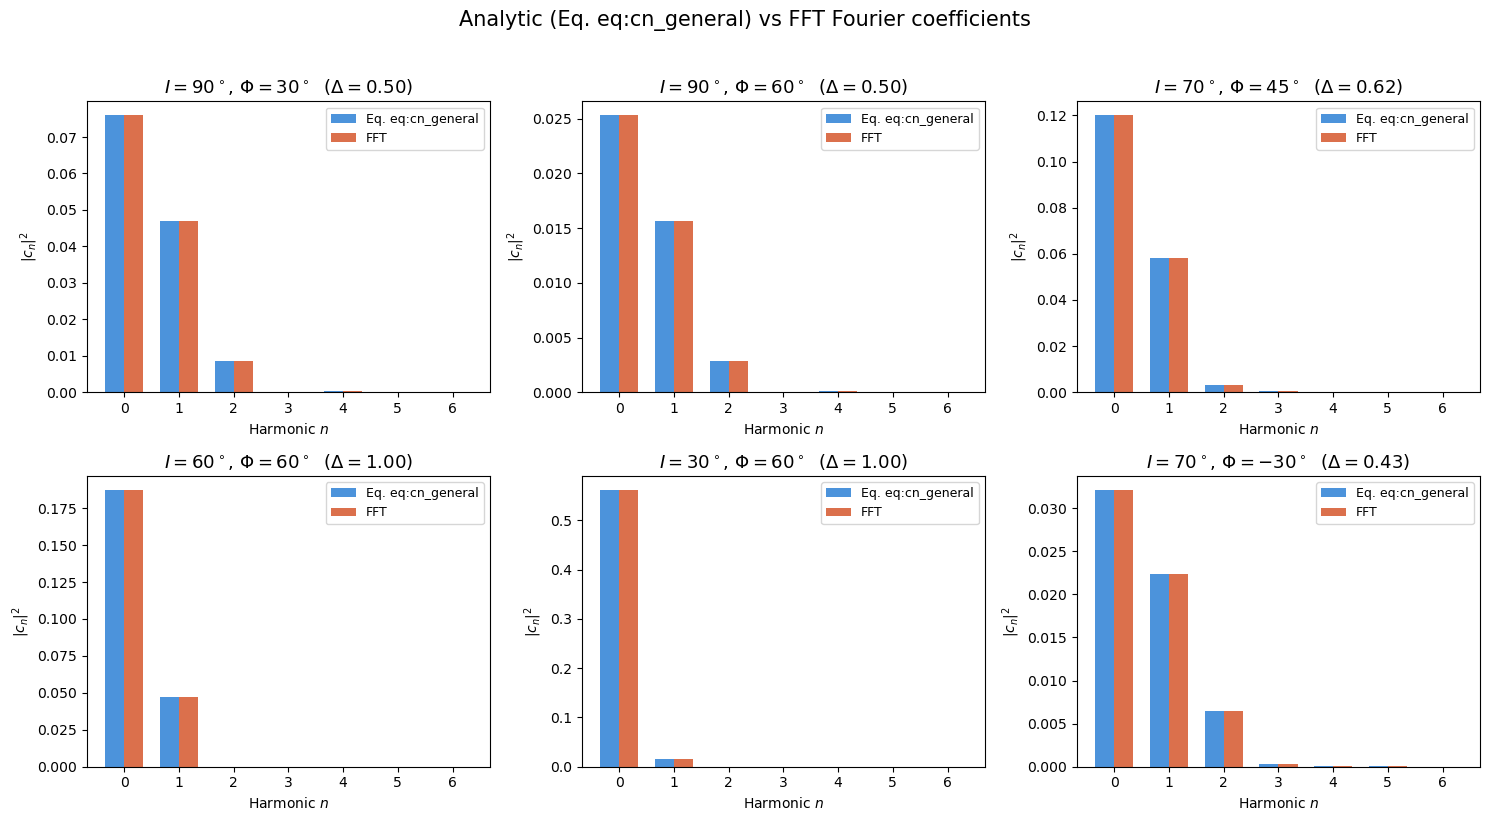

In [13]:
with plt.rc_context():   # importing spotgp applies its own matplotlib style; keep this notebook's
    from spotgp.visibility import _cn_general_jax

def theta_vis_of(b0_val, b1_val):
    """Half-width of the visibility window (Eq. eq:theta_vis): pi if always visible, 0 if never."""
    return np.arccos(np.clip(-b0_val / b1_val, -1.0, 1.0))

def cn_paper(nval, b0_val, b1_val, tv):
    """c_n from Eq. eq:cn_general, with the c_0 and c_{±1} limits printed after it (c_{-n} = c_n)."""
    nval = abs(nval)
    if nval == 0:
        return (b0_val * tv + b1_val * np.sin(tv)) / np.pi
    if nval == 1:
        return (b0_val * np.sin(tv) + b1_val * (tv + np.sin(tv) * np.cos(tv)) / 2) / np.pi
    return (b0_val * np.sin(nval * tv) / nval
            + b1_val / 2 * (np.sin((nval - 1) * tv) / (nval - 1)
                            + np.sin((nval + 1) * tv) / (nval + 1))) / np.pi

def fft_cn_sq(inc_val, phi_val, N_fft=8192):
    """|c_n|^2 via FFT of one rotation of V(t)."""
    t_one = np.linspace(0, 1, N_fft, endpoint=False)  # one period, in units of P
    cos_beta = np.cos(inc_val) * np.sin(phi_val) + np.sin(inc_val) * np.cos(phi_val) * np.cos(2*np.pi*t_one)
    V = np.maximum(cos_beta, 0)
    fft_vals = np.fft.fft(V) / N_fft
    return np.abs(fft_vals)**2

# Test cases (I, Phi) in degrees; Phi is latitude in [-90, 90]
cases = [(90, 30), (90, 60), (70, 45), (60, 60), (30, 60), (70, -30)]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
n_show = 6
harmonics = np.arange(n_show + 1)

for ax, (inc_deg, phi_deg) in zip(axes.flat, cases):
    inc_val = np.radians(inc_deg)
    phi_val = np.radians(phi_deg)

    b0_val = np.cos(inc_val) * np.sin(phi_val)
    b1_val = np.sin(inc_val) * np.cos(phi_val)
    tv = theta_vis_of(b0_val, b1_val)

    cn_sq_paper = np.array([cn_paper(nn, b0_val, b1_val, tv) for nn in harmonics])**2   # Eq. eq:cn_general
    cn_sq_fft = fft_cn_sq(inc_val, phi_val)[:n_show+1]
    cn_sq_spotgp = np.array([float(_cn_general_jax(nn, inc_val, phi_val)) for nn in harmonics])**2

    assert np.allclose(cn_sq_paper, cn_sq_spotgp, rtol=1e-10, atol=1e-15), (inc_deg, phi_deg)
    # The FFT of the kinked V(t) converges as 1/N_fft^2: compare relative to the largest |c_n|^2
    assert np.max(np.abs(cn_sq_paper - cn_sq_fft)) < 1e-6 * cn_sq_paper.max(), (inc_deg, phi_deg)
    print(f"I = {inc_deg:2d}°, Phi = {phi_deg:+3d}°: Delta = theta_vis/pi = {tv/np.pi:.3f};  "
          f"max abs diff in |c_n|^2: vs FFT {np.max(np.abs(cn_sq_paper - cn_sq_fft)):.1e}, "
          f"vs spotgp {np.max(np.abs(cn_sq_paper - cn_sq_spotgp)):.1e}")

    width = 0.35
    ax.bar(harmonics - width/2, cn_sq_paper, width, label='Eq. eq:cn_general', color='#0066CC', alpha=0.7)
    ax.bar(harmonics + width/2, cn_sq_fft, width, label='FFT', color='#CC3300', alpha=0.7)
    ax.set_title(rf'$I={inc_deg}^\circ$, $\Phi={phi_deg}^\circ$  ($\Delta = {tv/np.pi:.2f}$)', fontsize=13)
    ax.set_xlabel('Harmonic $n$')
    ax.set_ylabel('$|c_n|^2$')
    ax.set_xticks(harmonics)
    ax.legend(fontsize=9)

plt.suptitle('Analytic (Eq. eq:cn_general) vs FFT Fourier coefficients', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()